# **Assignment 2: Processing Datasets in Python**





*Authors:*

*   Camila García Vázquez **2177743**
*   Alan Zahir Lopez Rodriguez **2103115**
*   Ezequiel Sandoval Puerto **2061522**
*   Arleth Cassandra Andrade Cordova **1896113**

*Class schedule:* Thursday N3-N6


# **Part 1: Data Loading and Exploration**

**1. Call libraries , import pandas and load the file:**

In [ ]:
import pandas as pd

# Load the dataset that i attached
df = pd.read_csv('/diabetes.csv')

print("Dataset load successfully.")

Dataset load successfully.


Explanation:

> The Pandas library was imported in order to work with the table, considering that the file diabetes.csv was loaded using the "read_csv()" function and was attached to the Colab files folder.



**2. Show the first rows of my file:**

In [ ]:
# Display the first five rows of my document
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


Explanation:

> The first five rows were shown using the "head()" function, basically this lets us check that the dataset loaded correctly and allows us to see the variables included in each patient record.







**3. Check dimensions and data types:**

In [ ]:
# Display the dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the information about of the dataset
df.info()

Number of rows: 768
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


Explanation:


> Basically, the dataset contains 768 patient records and 9 variables. We asked it to tell us through the code, and we also used the "info()" function to identify all data types and check the number of non-null values in each column.



**4. Null values:**

In [ ]:
# Check if there are any null values
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Explanation:

> All null values were identified using the function "isnull().sum()." Doing this showed us that no null values were found in any of the columns of this version of the dataset. *(This is important because null values can affect the analysis, for example, if any glucose value were missing, it could result in incomplete answers)*


**5. Search for 0 values:**

In [ ]:
# Columns where the values are zero
columns_to_check_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Count zero values in the selected columns
zero_values_in_columns = (df[columns_to_check_zero] == 0).sum()

print("Zero values in clinical variables:")
print(zero_values_in_columns)

Zero values in clinical variables:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Explanation:


> Zero values in some clinical variables were checked to identify missing data; fortunately, in this dataset no problematic zero values were found.



**6. Descriptive stadistics:**

In [ ]:
# Generate descriptive statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Explanation:
> Here I used the "describe()" function to get descriptive statistics for all the numerical variables.



#  **Part 2: Data Cleaning and Normalization**

**1. Replace zero values**

In [ ]:
# Obtaining median and replacing zeros (when applicable)
for column in columns_to_check_zero:
    median = df[column].median()
    df[column] = df[column].replace(0, median)

# Show results
print("Zero values after replacement:")
print((df[columns_to_check_zero] == 0).sum()) # All the values must return zero

Zero values after replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Explanation:

The median of each selected clinical variable was calculated, and any zero values were replaced with the corresponding median. In this dataset, no zero values were found in these variables, so no replacements were necessary.

**2. Normalize**

In [ ]:
# Numerical columns to normalize
numerical_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

# Create a copy of the dataset
normalized_df = df.copy()

# Apply Min-Max Scaling
for column in numerical_columns:
    normalized_df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())

# Show results
print("\nNormalized data:")
print(normalized_df.head())


Normalized data:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.670968       0.489796       0.304348  0.186899  0.314928   
1     0.058824  0.264516       0.428571       0.239130  0.106370  0.171779   
2     0.470588  0.896774       0.408163       0.271739  0.186899  0.104294   
3     0.058824  0.290323       0.428571       0.173913  0.096154  0.202454   
4     0.000000  0.600000       0.163265       0.304348  0.185096  0.509202   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.234415  0.483333        1  
1                  0.116567  0.166667        0  
2                  0.253629  0.183333        1  
3                  0.038002  0.000000        0  
4                  0.943638  0.200000        1  


Explanation:

> I made an array for including the numerizal colums to normalize, used a "for" loop to step through the numerical columns, then applied the formula for normalizing.

#  **Part 3: Data Visualization**



3.1 Histogram of Glucose levels: before and after normalization

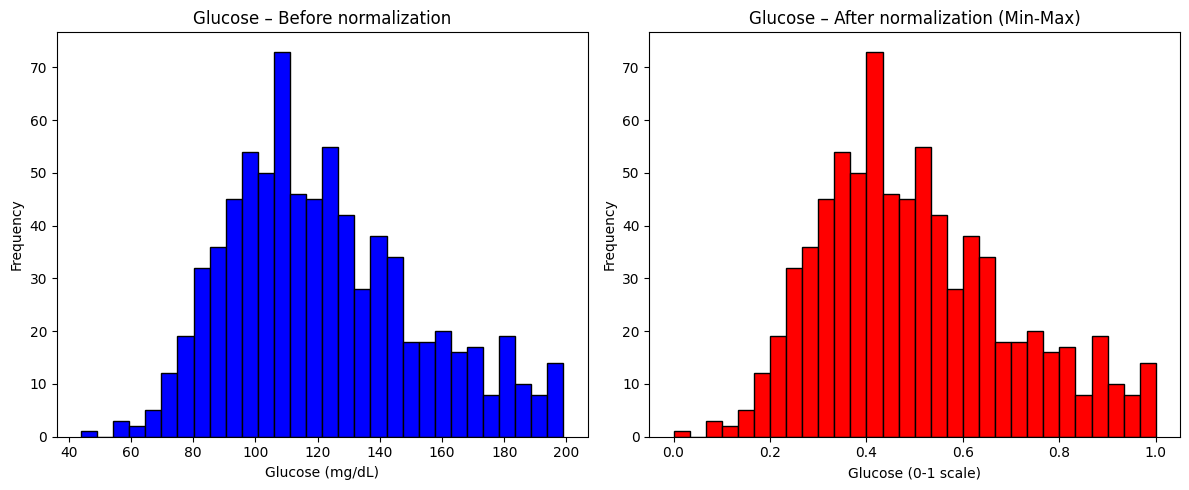

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Glucose"], bins=30, color="blue", edgecolor="black")
axes[0].set_title("Glucose – Before normalization")
axes[0].set_xlabel("Glucose (mg/dL)")
axes[0].set_ylabel("Frequency")

axes[1].hist(normalized_df["Glucose"], bins=30, color="red", edgecolor="black")
axes[1].set_title("Glucose – After normalization (Min-Max)")
axes[1].set_xlabel("Glucose (0-1 scale)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

3.2 Boxplot to identify outliers in Blood Pressure

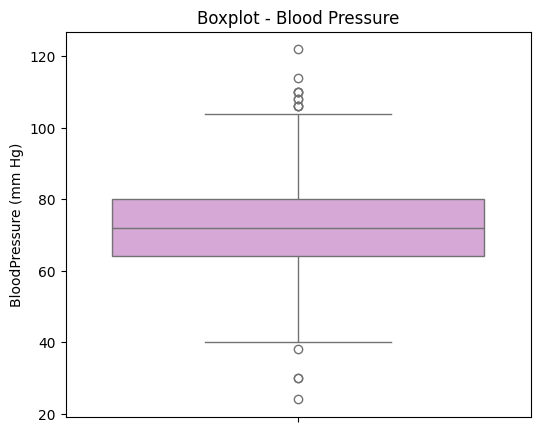

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.boxplot(y=df["BloodPressure"], color="plum")
plt.title("Boxplot - Blood Pressure")
plt.ylabel("BloodPressure (mm Hg)")
plt.show()

3.3 Scatter plot: Glucose vs BMI

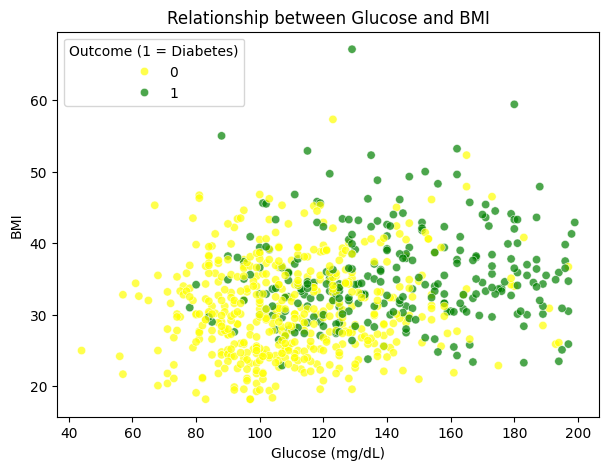

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Glucose", y="BMI", hue="Outcome", palette=["yellow", "green"], alpha=0.7)
plt.title("Relationship between Glucose and BMI")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.legend(title="Outcome (1 = Diabetes)")
plt.show()

3.4 Bar chart: patients with and without diabetes

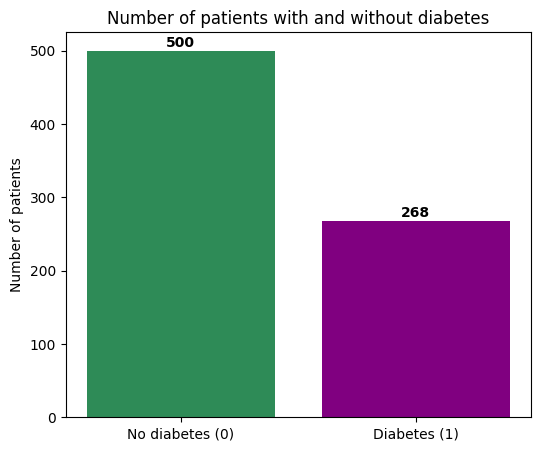

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
plt.bar(["No diabetes (0)", "Diabetes (1)"], outcome_counts.values, color=["seagreen", "purple"])
plt.title("Number of patients with and without diabetes")
plt.ylabel("Number of patients")

for i, value in enumerate(outcome_counts.values):
    plt.text(i, value + 5, str(value), ha="center", fontweight="bold")

plt.show()

print(outcome_counts)

# **Part 4: Answer the following questions**


1.   **What impact do missing values have on data analysis?**

Missing values can affect the accuracy of the analysis because they reduce the amount of available information. They can also cause errors or biased results if they are not handled correctly before using the data in a Machine Learning model.

2.   **How can we detect and handle outliers in biomedical datasets?**

Outliers can be detected using methods such as boxplots, descriptive statistics, or statistical measures like the interquartile range. After detecting them, they should be analyzed to determine whether they are valid measurements or errors. Depending on the case, they can be corrected, removed, or kept in the dataset.

3.   **What are some common causes of missing or incorrect data in biomedical studies?**

Missing or incorrect data can be caused by measurement errors, equipment problems, incomplete medical records, incorrect data entry, patient absence, or failures during data collection.

4.   **How does normalizing data improve the performance of Machine Learning models?**

Normalization places numerical variables on a similar scale. This prevents variables with larger numerical values from having more influence on the model and can help some Machine Learning algorithms work more efficiently.

5.   **Why is visualizing data an important step before applying Machine Learning models?**

Data visualization helps us understand the distribution of the variables, identify patterns, detect unusual values, and observe possible relationships between variables before training a Machine Learning model.

6.   **Why is preprocessing critical when working with medical datasets?**

Preprocessing is important because medical data may contain missing values, incorrect measurements, outliers, or variables with different scales. Cleaning and preparing the data helps improve its quality and makes the results of the Machine Learning model more reliable.

7.   **What ethical concerns should be considered when handling patient data?**

Patient information must be handled carefully to protect privacy and confidentiality. Personal information should be protected or anonymized, access to the data should be controlled, and the information should only be used for authorized purposes. It is also important to consider possible bias in the dataset because it could affect the fairness of the model.














